# PyDoseRT dose calculations on a water phantom
**Author:** Attila Simkó

This example shows how we can compute dose on a water phantom with a single beam in three simple steps:

1. Define a machine, phantom, and beam geometry,
2. Initialize the dose engine and run the dose calculations,
3. Compare the predicted dose with a reference dose distribution.

In [1]:
try:
    import pydosert
    print("pydosert is already installed")
except ImportError:
    !pip install pydosert

import urllib.request
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import pydosert as PDRT

# Use GPU when available; otherwise fall back to CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

pydosert is already installed


## Load a reference dataset

We use a TPS-computed dose distribution from a water-phantom as a reference against our PyDoseRT computed dose.

In [2]:
url = "https://raw.githubusercontent.com/UMU-DDI/PyDoseRT/main/examples/data/water_phantom.npz"
local_path = Path("data/water_phantom.npz")

# Make sure the folder exists
local_path.parent.mkdir(parents=True, exist_ok=True)

# Download only if the file is missing
if not local_path.exists():
    urllib.request.urlretrieve(url, local_path)
else:
    print(f"{local_path} already exists, skipping download.")

# Reference dose from a water-phantom. The dose values were scaled by 100 and saved as integers to save space. Hence the division by 100 here.
dose_ref = np.load("data/water_phantom.npz")["dose"] / 100

data/water_phantom.npz already exists, skipping download.


## Define the machine, phantom, and beam

Here we create the three main inputs for dose calculation:

- **MachineConfig**: simplified linac and beam-quality settings,
- **Phantom**: a homogeneous water volume,
- **Beam**: a single treatment beam with a chosen field size and isocenter.

This gives us a controlled setup that is easy to inspect.
Before computation, the phantom and beam are moved to the selected device and data type.

In [3]:
machine_config = PDRT.MachineConfig(number_of_leaf_pairs=10, 
                                    tpr_20_10=0.73, 
                                    mean_photon_energy_MeV=0.39
)

phantom = PDRT.Phantom.from_uniform_water(shape=(185, 167, 167), 
                                          spacing=(3.0, 3.0, 3.0)
)
phantom = phantom.to(dtype).to(device)

beam = PDRT.Beam.create(
    gantry_angle_deg=0.0,
    number_of_leaf_pairs=10, 
    field_size_mm=(100.0, 100.0),
    iso_center=(276.0, 100.0, 249.0)
)
beam = beam.to(device).to(dtype)


## Initialize the dose engine and compute dose

The dose engine combines the machine model, beam description, and density image.
We set the dose grid to the same shape and spacing as the reference so the comparison is straightforward.

In [4]:
engine = PDRT.DoseEngine(
    machine_config=machine_config,
    dose_grid_spacing=phantom.resolution,
    dose_grid_shape=dose_ref.shape,
    beam_template=beam,
    kernel_size=151,
    device=device,
    dtype=dtype)
dose_pred = engine.compute_dose(beam, 
                           density_image=phantom.density_image
).detach().cpu().numpy()[0, ...]

/home/bolo/Documents/PyDoseRT/src/pydosert/geometry/projections.py:70: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  leaf_widths = torch.tensor(


## Compare central slices

We first compare a central slice of:

- the PyDoseRT prediction,
- the reference dose,
- the error map.

This is a quick qualitative check of the overall shape and symmetry of the dose distribution.
Keep in mind, that the dose engine was not calibrated to the water phantom measurements. Instead of accuracy, this workflow focuses on the main functional components of PyDoseRT.

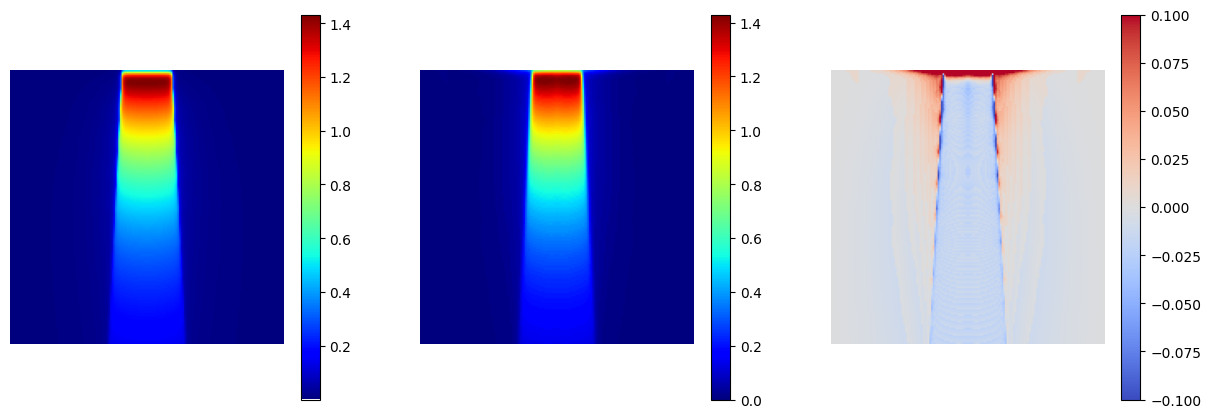

In [5]:
slice_idx = dose_pred.shape[0] // 2

plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(np.take(dose_pred, slice_idx, axis=0), cmap='jet')
plt.colorbar()
plt.axis('off')
plt.subplot(132)
plt.imshow(np.take(dose_ref, slice_idx, axis=0), cmap='jet')
plt.colorbar()
plt.axis('off')
plt.subplot(133)
plt.imshow(np.take((dose_ref - dose_pred), slice_idx, axis=0), cmap='coolwarm', vmin=-0.1, vmax=0.1)
plt.colorbar()
plt.axis('off')
plt.show()

## Compare 1D dose profiles

Finally, we compare line profiles through the volume:

- **left:** a depth-dose style profile,
- **right:** lateral profiles at several positions.

These plots make it easier to see where the predicted and reference doses agree or deviate.

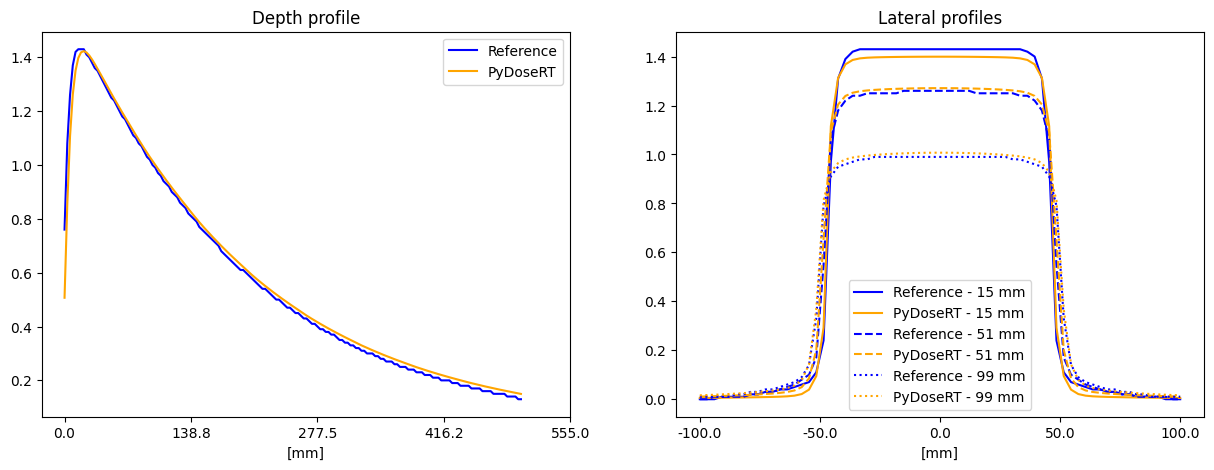

In [6]:
air_gap = 1

slice_idx = 84
depth_index = 93
num_ticks = 5

x = np.linspace(0, engine.dose_grid_shape[1], engine.dose_grid_shape[1])

plt.figure(figsize=(15, 5))

# Depth-direction profile
plt.subplot(121)
plt.plot(x, dose_ref[slice_idx, :, depth_index], label="Reference", color="blue")
plt.plot(x, dose_pred[slice_idx, :, depth_index], label="PyDoseRT", color="orange")
plt.legend()

new_xticks = np.linspace(0, engine.dose_grid_shape[0], num_ticks)
new_xtick_labels = np.round(
    np.linspace(0, engine.dose_grid_shape[0] * engine.dose_grid_spacing[0], num_ticks),
    1,
)

plt.xticks(new_xticks, new_xtick_labels)
plt.xlabel("[mm]")
plt.title("Depth profile")

# Lateral profiles at a few slice positions
plt.subplot(122)

num_ticks = 5
new_xticks = np.linspace(-100, 100, num_ticks)
new_xtick_labels = np.round(np.linspace(-100, 100, num_ticks), 1)
x = np.linspace(-100, 100, 67)

slices = [5, 17, 33]
line_styles = ["-", "--", ":"]

for i in range(len(slices)):
    plt.plot(
        x,
        dose_ref[59:126, slices[i], depth_index],
        label=f"Reference - {int(slices[i] * engine.dose_grid_spacing[1])} mm",
        color="blue",
        linestyle=line_styles[i],
    )
    plt.plot(
        x,
        dose_pred[59:126, slices[i], depth_index],
        label=f"PyDoseRT - {int(slices[i] * engine.dose_grid_spacing[1])} mm",
        color="orange",
        linestyle=line_styles[i],
    )

plt.legend()
plt.xticks(new_xticks, new_xtick_labels)
plt.xlabel("[mm]")
plt.title("Lateral profiles")

plt.show()